## 1. Load the dataset and display information

In [35]:
from sklearn.datasets import fetch_olivetti_faces
face_data = fetch_olivetti_faces()
X = face_data.data  # features
y = face_data.target  # labels

Shape of data: (400, 4096)
Shape of targets: (400,)
Number of classes: 40


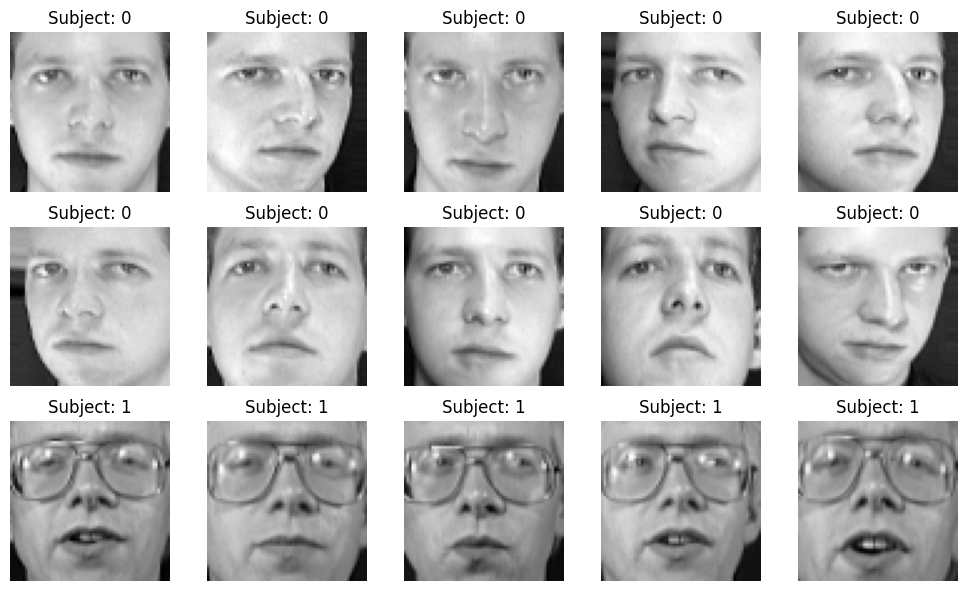

In [36]:
import numpy as np
import matplotlib.pyplot as plt

print(f"Shape of data: {X.shape}")
print(f"Shape of targets: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# Displaying some images
fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Subject: {y[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# 2. Splitting dataset

In [37]:
X_by_subject = []
y_by_subject = []

unique_subjects = np.unique(y)

for subject_id in unique_subjects:
    subject_mask = (y == subject_id)
    X_subject = X[subject_mask]
    y_subject = y[subject_mask]
    X_by_subject.append(X_subject)
    y_by_subject.append(y_subject)

print(f"Number of subjects: {len(X_by_subject)}")
print(f"Shape of data for the first subject: {X_by_subject[0].shape}")
print(f"Shape of labels for the first subject: {y_by_subject[0].shape}")

Number of subjects: 40
Shape of data for the first subject: (10, 4096)
Shape of labels for the first subject: (10,)


In [38]:
X_train_list = []
X_val_list = []
X_test_list = []
y_train_list = []
y_val_list = []
y_test_list = []

In [39]:
for X_subject, y_subject in zip(X_by_subject, y_by_subject):
    X_train_list.append(X_subject[:7])
    y_train_list.append(y_subject[:7])
    X_val_list.append(X_subject[7:8])
    y_val_list.append(y_subject[7:8])
    X_test_list.append(X_subject[8:])
    y_test_list.append(y_subject[8:])

In [40]:
X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_val = np.concatenate(X_val_list, axis=0)
y_val = np.concatenate(y_val_list, axis=0)
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (280, 4096)
Shape of y_train: (280,)
Shape of X_val: (40, 4096)
Shape of y_val: (40,)
Shape of X_test: (80, 4096)
Shape of y_test: (80,)


# 3. Creating design matrix

In [41]:
# The images are already flattened into 4096-dimensional vectors in the original dataset
# The training data is already stored in X_train with shape (280, 4096) which is N x 4096 where N=280

# X_train is already the design matrix
X_design_matrix = X_train

print(f"Dimensions of the design matrix X: {X_design_matrix.shape}")

Dimensions of the design matrix X: (280, 4096)


# 4. Computing mean image

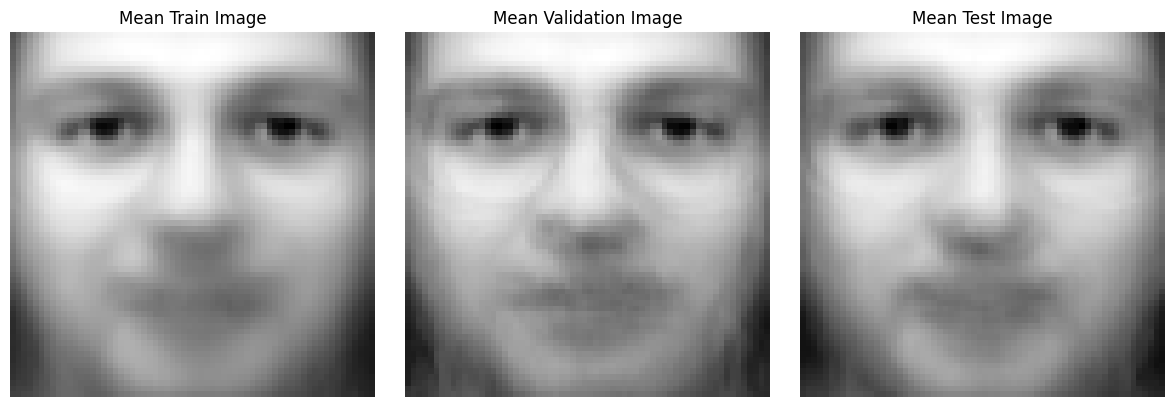

In [42]:
# Computing the mean image for each set
mean_train_image = np.mean(X_train, axis=0)
mean_val_image = np.mean(X_val, axis=0)
mean_test_image = np.mean(X_test, axis=0)

# Reshaping the mean images back to 64x64
mean_train_image_reshaped = mean_train_image.reshape(64, 64)
mean_val_image_reshaped = mean_val_image.reshape(64, 64)
mean_test_image_reshaped = mean_test_image.reshape(64, 64)

# Displaying the mean images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(mean_train_image_reshaped, cmap='gray')
axes[0].set_title("Mean Train Image")
axes[0].axis('off')

axes[1].imshow(mean_val_image_reshaped, cmap='gray')
axes[1].set_title("Mean Validation Image")
axes[1].axis('off')

axes[2].imshow(mean_test_image_reshaped, cmap='gray')
axes[2].set_title("Mean Test Image")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 5. Performing PCA from scratch

In [43]:
X_train_mean_subtracted = X_train - mean_train_image
print(f"Shape of X_train_mean_subtracted: {X_train_mean_subtracted.shape}")

Shape of X_train_mean_subtracted: (280, 4096)


In [44]:
covariance_matrix = np.cov(X_train_mean_subtracted, rowvar=False)
print(f"Shape of covariance matrix: {covariance_matrix.shape}")

Shape of covariance matrix: (4096, 4096)


In [45]:
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

print(f"Shape of eigenvalues: {eigenvalues.shape}")
print(f"Shape of eigenvectors: {eigenvectors.shape}")

Shape of eigenvalues: (4096,)
Shape of eigenvectors: (4096, 4096)


In [46]:
eigenpairs = [(np.abs(eigenvalues[i]), eigenvectors[:,i]) for i in range(len(eigenvalues))]
eigenpairs.sort(key=lambda k: k[0], reverse=True)

sorted_eigenvalues = np.array([pair[0] for pair in eigenpairs])
sorted_eigenvectors = np.array([pair[1] for pair in eigenpairs])

print(f"Shape of sorted eigenvalues: {sorted_eigenvalues.shape}")
print(f"Shape of sorted eigenvectors: {sorted_eigenvectors.shape}")

Shape of sorted eigenvalues: (4096,)
Shape of sorted eigenvectors: (4096, 4096)


In [47]:
k_values = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 279]
accuracy_scores = {}

In [48]:
for k in k_values:
    print(f"Processing k = {k}")

Processing k = 5
Processing k = 10
Processing k = 15
Processing k = 20
Processing k = 25
Processing k = 30
Processing k = 40
Processing k = 50
Processing k = 75
Processing k = 100
Processing k = 150
Processing k = 200
Processing k = 279


In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 279]
accuracy_scores = {}

for k in k_values:
    print(f"Processing k = {k}")

    # Selecting top k eigenvectors
    top_k_eigenvectors = sorted_eigenvectors[:, :k]

    # Projecting training and validation data
    X_train_pca = X_train_mean_subtracted @ top_k_eigenvectors
    X_val_mean_subtracted = X_val - mean_train_image
    X_val_pca = X_val_mean_subtracted @ top_k_eigenvectors

    # Converting to real numbers
    X_train_pca = np.real(X_train_pca)
    X_val_pca = np.real(X_val_pca)


    # Training KNN and predicting
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train_pca, y_train)
    y_pred = knn.predict(X_val_pca)

    # Computing and reporting accuracy
    accuracy = accuracy_score(y_val, y_pred)
    accuracy_scores[k] = accuracy

    print(f"Accuracy for k={k}: {accuracy}")

Processing k = 5
Accuracy for k=5: 0.225
Processing k = 10
Accuracy for k=10: 0.475
Processing k = 15
Accuracy for k=15: 0.6
Processing k = 20
Accuracy for k=20: 0.65
Processing k = 25
Accuracy for k=25: 0.7
Processing k = 30
Accuracy for k=30: 0.75
Processing k = 40
Accuracy for k=40: 0.8
Processing k = 50
Accuracy for k=50: 0.875
Processing k = 75
Accuracy for k=75: 0.9
Processing k = 100
Accuracy for k=100: 0.925
Processing k = 150
Accuracy for k=150: 0.9
Processing k = 200
Accuracy for k=200: 0.95
Processing k = 279
Accuracy for k=279: 0.925


# 6. Plot the accuracy as a function of k

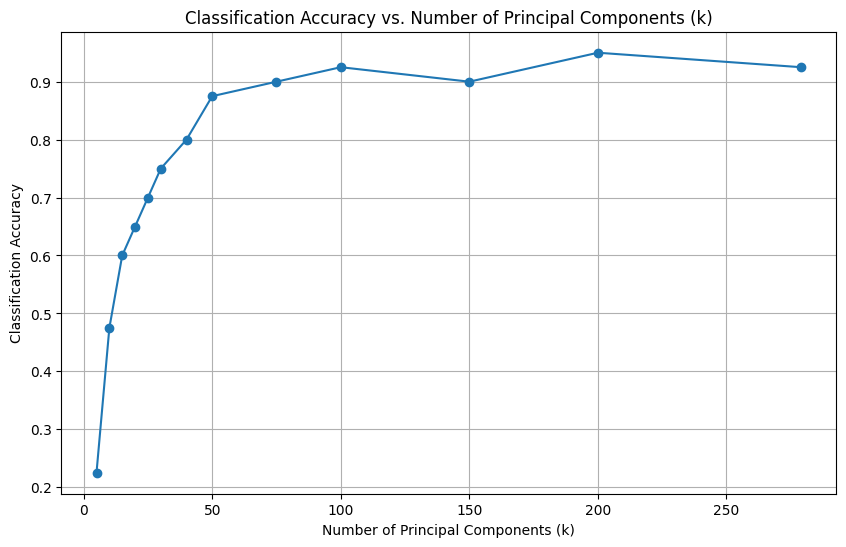

In [50]:
import matplotlib.pyplot as plt

k_values = list(accuracy_scores.keys())
accuracy_list = list(accuracy_scores.values())

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_list, marker='o')
plt.title("Classification Accuracy vs. Number of Principal Components (k)")
plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Classification Accuracy")
plt.grid(True)
plt.show()

# 7. Picking a good k

In [51]:
# Sorting accuracy scores by k
sorted_k_values = sorted(accuracy_scores.keys())

best_k = None
highest_accuracy = 0

# Finding the k with the highest accuracy, prioritizing lower k in case of ties
for k in sorted_k_values:
    accuracy = accuracy_scores[k]
    if accuracy > highest_accuracy:
        highest_accuracy = accuracy
        best_k = k
    elif accuracy == highest_accuracy:
        # Tie-breaking: choosing the lower k
        if best_k is None or k < best_k:
             best_k = k


print(f"The value of k that gives a good trade-off between accuracy and number of eigenvectors is: {best_k} with an accuracy of {accuracy_scores[best_k]:.3f}")

The value of k that gives a good trade-off between accuracy and number of eigenvectors is: 200 with an accuracy of 0.950


# 8. Visualizing the k eigen vectors as eigenfaces for the chosen value of k

Shape of top 200 eigenvectors: (4096, 200)


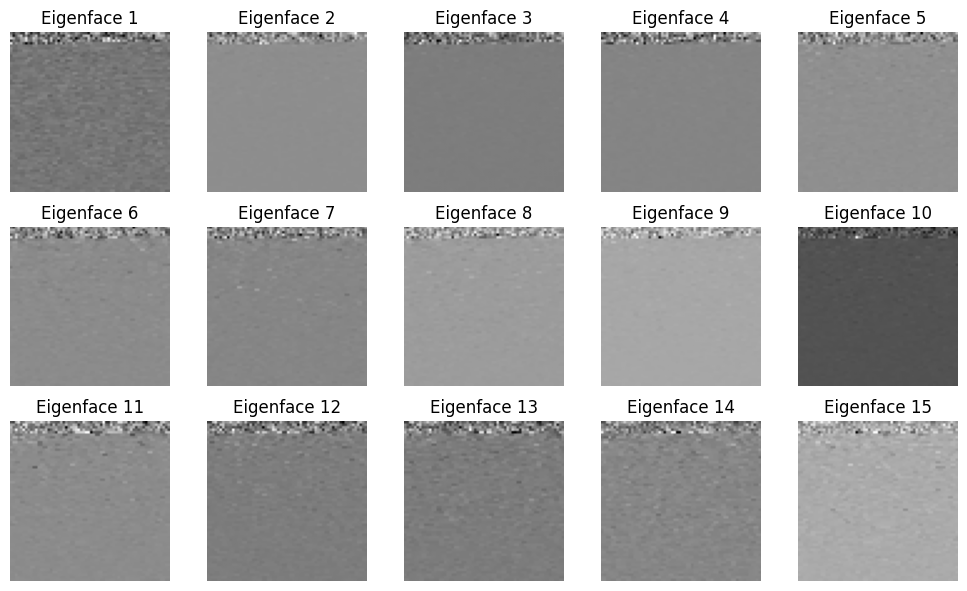

In [52]:
# Reshaping the top k eigenvectors to 64x64 to visualize as eigenfaces
best_k_eigenvectors = sorted_eigenvectors[:, :best_k]

print(f"Shape of top {best_k} eigenvectors: {best_k_eigenvectors.shape}")

# Displaying the first few eigenfaces
num_eigenfaces_to_display = min(best_k, 15) # Display up to 15 eigenfaces

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    if i < num_eigenfaces_to_display:
        # Eigenvectors might have complex values, taking the real part for visualization
        eigenface = np.real(best_k_eigenvectors[:, i]).reshape(64, 64)
        ax.imshow(eigenface, cmap='gray')
        ax.set_title(f"Eigenface {i+1}")
        ax.axis('off')
    else:
        ax.axis('off') # Turning off unused subplots

plt.tight_layout()
plt.show()

# 9. Classification accuracy on test set

In [53]:
# Projecting the mean-subtracted test data onto the top k eigenvectors
X_test_mean_subtracted = X_test - mean_train_image
X_test_pca = X_test_mean_subtracted @ best_k_eigenvectors

# Converting to real numbers
X_test_pca = np.real(X_test_pca)

# Retraining the KNN classifier with the optimal best_k
knn_final = KNeighborsClassifier(n_neighbors=1)
X_train_pca_final = np.real(X_train_mean_subtracted @ best_k_eigenvectors)
knn_final.fit(X_train_pca_final, y_train)


# Predicting labels for the test set using the trained KNN classifier
y_test_pred = knn_final.predict(X_test_pca)

# Computing and reporting accuracy on the test set
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Classification accuracy on the test set with k={best_k}: {test_accuracy:.3f}")

Classification accuracy on the test set with k=200: 0.863


# 10. Performing PCA using scikit-learn

In [54]:
from sklearn.decomposition import PCA
pca_sklearn = PCA(n_components=best_k)

# Fitting PCA on the training data
pca_sklearn.fit(X_train)

PCA(n_components=200)

In [55]:
# Transforming training data
X_train_pca_sklearn = pca_sklearn.transform(X_train)

# Transforming test data
X_test_pca_sklearn = pca_sklearn.transform(X_test)

print(f"Shape of X_train_pca_sklearn: {X_train_pca_sklearn.shape}")
print(f"Shape of X_test_pca_sklearn: {X_test_pca_sklearn.shape}")

Shape of X_train_pca_sklearn: (280, 200)
Shape of X_test_pca_sklearn: (80, 200)


In [56]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiating a 1-nearest neighbor classifier
knn_sklearn = KNeighborsClassifier(n_neighbors=1)

# Training the classifier
knn_sklearn.fit(X_train_pca_sklearn, y_train)

KNeighborsClassifier(n_neighbors=1)

In [57]:
from sklearn.metrics import accuracy_score

# Predicting the labels for the PCA-transformed test data
y_test_pred_sklearn = knn_sklearn.predict(X_test_pca_sklearn)

# Computing the classification accuracy
test_accuracy_sklearn = accuracy_score(y_test, y_test_pred_sklearn)

# Printing the test accuracy
print(f"Classification accuracy on the test set with k={best_k} (scikit-learn PCA): {test_accuracy_sklearn:.3f}")

Classification accuracy on the test set with k=200 (scikit-learn PCA): 0.863


# Comparison

In [58]:
print(f"Accuracy with manual PCA: {test_accuracy:.3f}")
print(f"Accuracy with scikit-learn PCA: {test_accuracy_sklearn:.3f}")

print("\nComparison:")
if abs(test_accuracy - test_accuracy_sklearn) < 1e-6:
    print("The accuracy scores from the manual and scikit-learn PCA implementations are very close.")
elif test_accuracy > test_accuracy_sklearn:
    print("The manual PCA implementation achieved slightly higher accuracy.")
else:
    print("The scikit-learn PCA implementation achieved slightly higher accuracy.")

print("Any small differences could be due to variations in floating-point calculations between the two implementations.")

Accuracy with manual PCA: 0.863
Accuracy with scikit-learn PCA: 0.863

Comparison:
The accuracy scores from the manual and scikit-learn PCA implementations are very close.
Any small differences could be due to variations in floating-point calculations between the two implementations.
